<a href="https://colab.research.google.com/github/legong-beep/MPM_204_Gong/blob/main/assignments/01_Assignment_Logistic_Regression_HW1%20part%202%20complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Instructions
* For all questions, you must show your work. This will enable us to understand your thought process, give partial credit, and prevent crude cheating.
* Please ensure that you are not simply copying each other's code but rather striving to understand and learn from the work.
* Provide the R code at the end of your solution and include R commands along with R outputs to clearly describe your solutions.

### Dataset Overview
* The dataset contains information about medical diagnostic measurements for predicting diabetes in Pima Indian women. The outcome variable is `Outcome`, where:
* 1 indicates diabetes-positive.
* 0 indicates diabetes-negative.

**The dataset includes the following variables:**

* `Pregnancies`: Number of pregnancies.
* `Glucose`: Plasma glucose concentration.
* `BloodPressure`: Diastolic blood pressure (mm Hg).
* `SkinThickness`: Triceps skinfold thickness (mm).
* `Insulin`: 2-Hour serum insulin (mu U/ml).
* `BMI`: Body mass index (weight in kg/(height in m)^2).
* `DiabetesPedigreeFunction`: Diabetes pedigree function (genetic risk).
* `Age`: Age (years).
* `Outcome`: Binary outcome (0 or 1).

`Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.`

## Questions

### Q0: Install necessary packages
Install and load the following packages:
`tidyverse`
`dplyr`
`ggplot2`

In [1]:
# Install packages
install.packages("tidyverse")
install.packages("dplyr")
install.packages("ggplot2")

# Load packages
library(tidyverse)
library(dplyr)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### Q1: Load the dataset
* Read the Pima Indians Diabetes Database into R.  
Points: 2

Answer here

In [2]:
list.files(path = "/content", recursive = TRUE)

[1] "diabetes.csv"                            
[2] "sample_data/anscombe.json"               
[3] "sample_data/california_housing_test.csv" 
[4] "sample_data/california_housing_train.csv"
[5] "sample_data/mnist_test.csv"              
[6] "sample_data/mnist_train_small.csv"       
[7] "sample_data/README.md"

In [ ]:
df <- read.csv("/diabetes.csv")

In [3]:
# check that upload worked
head(df)

                                              
1 function (x, df1, df2, ncp, log = FALSE)    
2 {                                           
3     if (missing(ncp))                       
4         .Call(C_df, x, df1, df2, log)       
5     else .Call(C_dnf, x, df1, df2, ncp, log)
6 }                                           

### Q2: Explore the dataset
1. How many rows and columns are in the dataset?
2. How many columns are categorical, and how many are continuous?
Points: 3

### Q3: Create a random subset
Create a random subset of 500 rows from the dataset using the following code:

In [5]:
# Q2
#Load the dataset
df <- read.csv("/content/diabetes.csv")

# 1. Rows and columns
dim(df)        # shows rows x columns
nrow(df)       # rows only
ncol(df)       # columns only

# 2. Column types
str(df)

#Q3
# Set a seed so your results are reproducible
set.seed(123)

# Create the random subset
model_data <- df[sample(nrow(df), 500), ]

[1] 768   9

[1] 768

[1] 9

'data.frame':	768 obs. of  9 variables:
 $ Pregnancies             : int  6 1 8 1 0 5 3 10 2 8 ...
 $ Glucose                 : int  148 85 183 89 137 116 78 115 197 125 ...
 $ BloodPressure           : int  72 66 64 66 40 74 50 0 70 96 ...
 $ SkinThickness           : int  35 29 0 23 35 0 32 0 45 0 ...
 $ Insulin                 : int  0 0 0 94 168 0 88 0 543 0 ...
 $ BMI                     : num  33.6 26.6 23.3 28.1 43.1 25.6 31 35.3 30.5 0 ...
 $ DiabetesPedigreeFunction: num  0.627 0.351 0.672 0.167 2.288 ...
 $ Age                     : int  50 31 32 21 33 30 26 29 53 54 ...
 $ Outcome                 : int  1 0 1 0 1 0 1 0 1 1 ...


Use this subset (`model_data`) for all subsequent questions.  
Points: 1

### Q4: Tabulate and visualize the outcome variable
1. Tabulate and plot the distribution of the outcome variable (Outcome).  
2. Save this plot as a PDF file (4 inches wide, 3 inches tall) and submit it along with your assignment.
Points: 3




  0   1 
322 178 

agg_record_8f378833d8d 
                     2

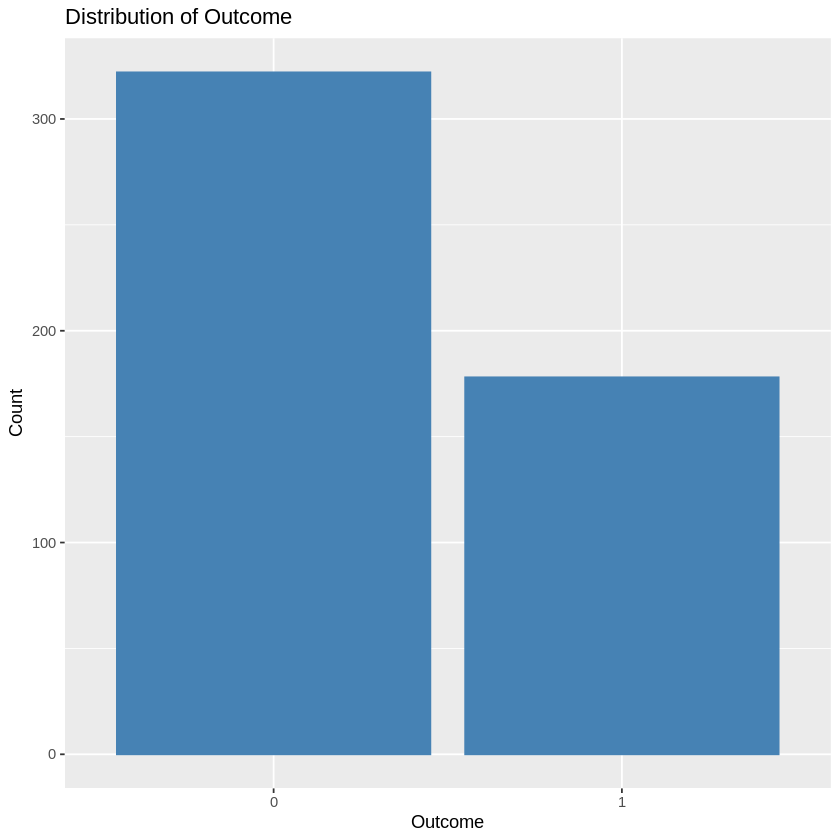

In [6]:
#tabulating the outcome variable
table(model_data$Outcome)

#plotting distribution
p <- ggplot(model_data, aes(x = factor(Outcome))) +
  geom_bar(color = 'steelblue', fill = 'steelblue') +
  xlab('Outcome') + ylab('Count') +
  labs(title = "Distribution of Outcome")
p

#save as PDF
pdf("outcome_plot.pdf", width = 4, height = 3)
p
dev.off()

### Q5: Explore covariates
1. Choose five covariates that you think might affect diabetes prediction based on general understanding.
2. For each covariate, create a table showing the distribution of values for each outcome (0 or 1).
3. Generate bar plots for these covariates using facet_grid in ggplot2.
Points: 5



In [7]:
#choosing 5 covariates that might affect diabetes

#table for each covariate showing distribution of values
# Convert Outcome to factor so it reads as categories
model_data$Outcome <- factor(model_data$Outcome)

# Tables showing distribution by outcome
table(model_data$Outcome, cut(model_data$Glucose, breaks=5))
table(model_data$Outcome, cut(model_data$BMI, breaks=5))
table(model_data$Outcome, cut(model_data$Age, breaks=5))
table(model_data$Outcome, cut(model_data$BloodPressure, breaks=5))
table(model_data$Outcome, cut(model_data$Pregnancies, breaks=5))

   
    (-0.199,39.8] (39.8,79.6] (79.6,119] (119,159] (159,199]
  0             2          21        188       100        11
  1             2           0         41        79        56

   
    (-0.0671,13.4] (13.4,26.8] (26.8,40.3] (40.3,53.7] (53.7,67.2]
  0              5          99         193          24           1
  1              2           8         133          33           2

   
    (20.9,33] (33,45] (45,57] (57,69] (69,81.1]
  0       227      59      21      14         1
  1        85      55      25      12         1

   
    (-0.11,22] (22,44] (44,66] (66,88] (88,110]
  0         13       5     114     172       18
  1         11       1      37     108       21

   
    (-0.017,3.4] (3.4,6.8] (6.8,10.2] (10.2,13.6] (13.6,17]
  0          203        74         34          11         0
  1           75        44         47           8         4

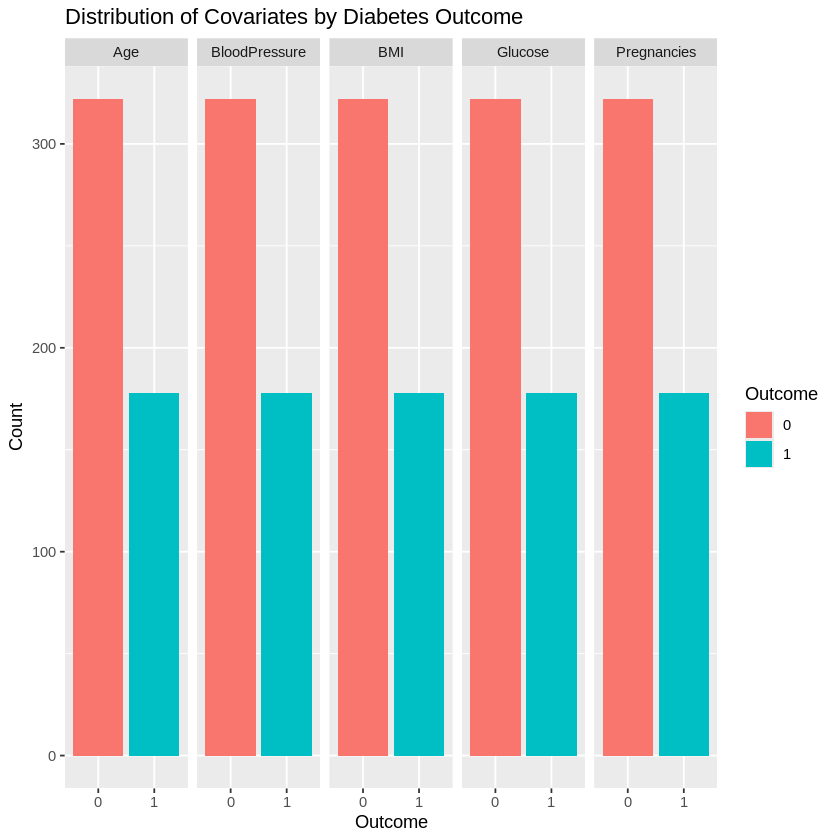

In [8]:
#bar plots for covariates
library(ggplot2)
library(tidyr)

#reshape data for plotting
plot_data <- pivot_longer(model_data,
                          cols = c(Glucose, BMI, Age, BloodPressure, Pregnancies),
                          names_to = "Covariate",
                          values_to = "Value")

#bar plot with facet_grid
ggplot(plot_data, aes(x = Outcome, fill = Outcome)) +
  geom_bar() +
  facet_grid(~ Covariate) + #split into separate panels, one for each coviariate
  xlab("Outcome") + ylab("Count") + #label axes and add title
  labs(title = "Distribution of Covariates by Diabetes Outcome")

## Q6: Understanding the problem
1. What is the outcome variable in this dataset?
2. Is the outcome continuous, count, or binary?
3. Based on this, which type of GLM family is appropriate?

In [9]:
#Answer 1: 0 or 1, or diabetes or no diabetes
#Answer 2: Binary
#Answer 3: Binomial

## Q7 Writing the model
1. Write the mathematical form of the model:
2. What is being modeled on the left-hand side?
3. What transformation is applied (logit)?
4. How would you express (logit) this in words?

ANSWERS:

1) logit(p) = β₀ + β₁X₁ + β₂X₂ + β₃X₃ + β₄X₄ + β₅X₅
2) On the left side, probabilty of having diabetes (the outcome 0 or 1)
3) logit
4) Logit is odds of the probability of having diabetes dividied by the probability of not having diabetes, and then taking the odds and transforming the probability to have no limits, rather than be bound bewteen 0 and 1.


### Q7: Run univariate logistic regression models
1. Perform univariate logistic regression for each of the five selected covariates using the `glm()` function with a binomial family.
2. Identify which variable has the highest beta coefficient and explain its significance.
Points: 10



In [10]:
#run univariate models for each covariate
model_Glucose <- glm(Outcome ~ Glucose, data = model_data, family = "binomial")
model_BMI <- glm(Outcome ~ BMI, data = model_data, family = "binomial")
model_Age <- glm(Outcome ~ Age, data = model_data, family = "binomial")
model_BloodPressure <- glm(Outcome ~ BloodPressure, data = model_data, family = "binomial")
model_Pregnancies <- glm(Outcome ~ Pregnancies, data = model_data, family = "binomial")

summary(model_Glucose)
summary(model_BMI)
summary(model_Age)
summary(model_BloodPressure)
summary(model_Pregnancies)


Call:
glm(formula = Outcome ~ Glucose, family = "binomial", data = model_data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -5.458299   0.534501  -10.21   <2e-16 ***
Glucose      0.038691   0.004107    9.42   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 527.29  on 498  degrees of freedom
AIC: 531.29

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Outcome ~ BMI, family = "binomial", data = model_data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -3.63118    0.50357  -7.211 5.56e-13 ***
BMI          0.09250    0.01482   6.241 4.36e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 603.74  on 498  degrees of freedom
AIC: 607.74

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Outcome ~ Age, family = "binomial", data = model_data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.008000   0.296236  -6.778 1.22e-11 ***
Age          0.041934   0.008224   5.099 3.41e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 623.69  on 498  degrees of freedom
AIC: 627.69

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Outcome ~ BloodPressure, family = "binomial", data = model_data)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)   
(Intercept)   -1.209679   0.371143  -3.259  0.00112 **
BloodPressure  0.008920   0.005149   1.732  0.08322 . 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 647.91  on 498  degrees of freedom
AIC: 651.91

Number of Fisher Scoring iterations: 4



Call:
glm(formula = Outcome ~ Pregnancies, family = "binomial", data = model_data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.07768    0.14884  -7.240 4.47e-13 ***
Pregnancies  0.12216    0.02798   4.365 1.27e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 651.08  on 499  degrees of freedom
Residual deviance: 631.40  on 498  degrees of freedom
AIC: 635.4

Number of Fisher Scoring iterations: 4


In [ ]:
#pregnany has the highest beta coefficient at 0.122.
#This is significant because for eavery pregnancy, the log odds of having diabetes increases by 0.122.
#pregnancy has the highest beta, but it may not be the most important predictors when taking AIC under consideration.

### Q8: Interpret odds ratios
1. For each covariate in your final model:
2. Calculate odds ratios manually from model coefficients.
3. Interpret these odds ratios in words, considering whether they are statistically significant.
4. Use `sjPlot::tab_model()` to verify your calculations and compare results.
Points: 10



In [11]:
#calculate ORs for each covariate; exponentiating beta coefficinets
exp(coef(model_Glucose))
exp(coef(model_BMI))
exp(coef(model_Age))
exp(coef(model_BloodPressure))
exp(coef(model_Pregnancies))

(Intercept)     Glucose 
0.004260795 1.039449054

(Intercept)         BMI 
 0.02648498  1.09691743

(Intercept)         Age 
  0.1342569   1.0428252

(Intercept) BloodPressure 
     0.298293      1.008960

(Intercept) Pregnancies 
  0.3403851   1.1299302

3. ANSWERS:

- Glucose: for every 1 unit increase in glucose, the odds of having diabetes increases by 1.039 times.

- BMI: for every one unit increase in BMI, the odds of having diabetes increases by 1.097 times.
- Age: for every one year increase in age, the odds of having diabetes increases by 1.043 times.
- BP: for every one unit increase in BP, the odds of having diabetes increases by 1.009.
- Pregnancy: for every one additional pregnancy, the odds of having diabetes increases by 1.129 times.

In [ ]:
#CANVAS SAYS QUESTIONS 1-9

### Q9: Model diagnostics (do not attempt, for next assingment)
1. How many properties can you access from a fitted logistic regression model object in R? Use names(YOURMODEL) to explore.
2. Discuss any two properties that provide insights into model performance or interpretation.
3. What is deviance for your model?
4. What does a large reduction in deviance indicate?
5. How does deviance relate to:  
  model fit?  
  likelihood?  
Points: 10



In [12]:
#explore model properties
names(model_Glucose)

[1] "coefficients"      "residuals"         "fitted.values"    
 [4] "effects"           "R"                 "rank"             
 [7] "qr"                "family"            "linear.predictors"
[10] "deviance"          "aic"               "null.deviance"    
[13] "iter"              "weights"           "prior.weights"    
[16] "df.residual"       "df.null"           "y"                
[19] "converged"         "boundary"          "model"            
[22] "call"              "formula"           "terms"            
[25] "data"              "offset"            "control"          
[28] "method"            "contrasts"         "xlevels"

In [13]:
#chose coefficients and deviance
#access properties
model_Glucose$coefficients
model_Glucose$deviance

(Intercept)     Glucose 
-5.45829949  0.03869082

[1] 527.2947

In [14]:
#deviance of model
model_Glucose$deviance
model_Glucose$null.deviance

[1] 527.2947

[1] 651.082

ANSWERS:

Large reduction in deviance indicates the covariate explains the outcome well, or that it is informative and not only noise. It also indicates it is better than the null, in other words,it is better than just guessing.

Deviance relates to model fit in that lower deviance means better fit; the model is doing a better job at predicting diabetes. As for likelihood, the lower the deviance, the higher the likelihood; and the higher the deviance, the lower the likelihood.

## Q10 : Perform Residual diagnostics (do not attempt, for next assingment)
1. What types of residuals are available in GLMs?
2. Why do residual plots look different for binary outcomes?
3. Why do we see two bands in residual plots?
4. Which residual is generally preferred for GLMs and why?

ANSWERS:
1. Response residuals: simplely subtract what actually happened minus what the model predicted/observed minus predicted value; Pearson residual: adjusts based on how much variaibility was expected at that probability/adjusts for variance chnages with the mean; Deviance residual: Instead of looking at the same gap between predicted and observed, it asks how much did one thing hurt the overal model fit/based on how much each observatio contributes to overall deviance (preferred)

2. Because for binary outcomes, they are limited and can only be 0 or 1. They aren't continuous and therefore cant be a decimal between 0 or 1. The plot does not look like a normal regression.

3. Because of the 0 to 1 constraint. 1 and 0 form a band each, with nothing in between.

4. Deviance residulas are generally preferred because they behave more like normal regression residuals and are easier to interpret. They more closely reflect how much each observation affects the overall fit.

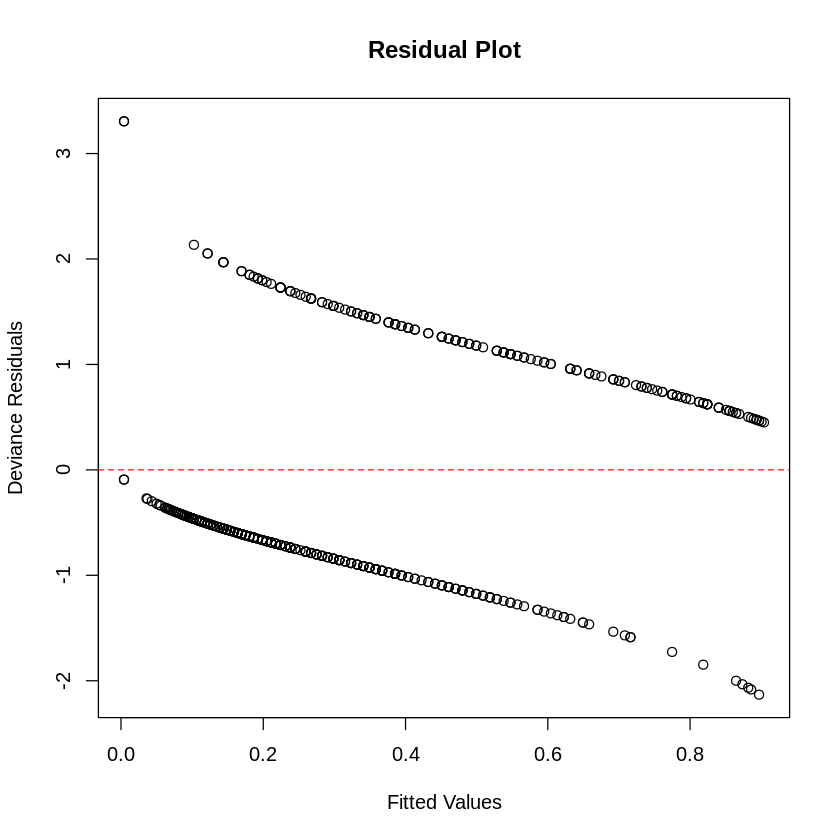

In [15]:
# Get deviance residuals (the preferred type)
res <- residuals(model_Glucose, type = "deviance")

# Plot residuals vs fitted values
plot(fitted(model_Glucose), res,
     main = "Residual Plot",
     xlab = "Fitted Values",
     ylab = "Deviance Residuals")
abline(h = 0, col = "red", lty = 2)

## Q11: Run analysis for Influential observations using Cook's distance calculations (do not attempt, for next assingment))
1. What is Cook’s Distance measuring?
2. What does a large Cook’s Distance imply?
3. Should influential points always be removed? Why or why not?

ANSWERS:
1. Cook's distance measures how much each individual observation influences overal model; how much the results would change if that observation were to be removed.
2. A large Cook's value implies that observation is having an outsized effect on the model, which is pulling the results more than a typical observation does.
3. No, they should not always be removed. Before considering removing, they should be investigated if they are real data points, as removing it could make the model less accurate. They should be removed only if confirmed as data errors.

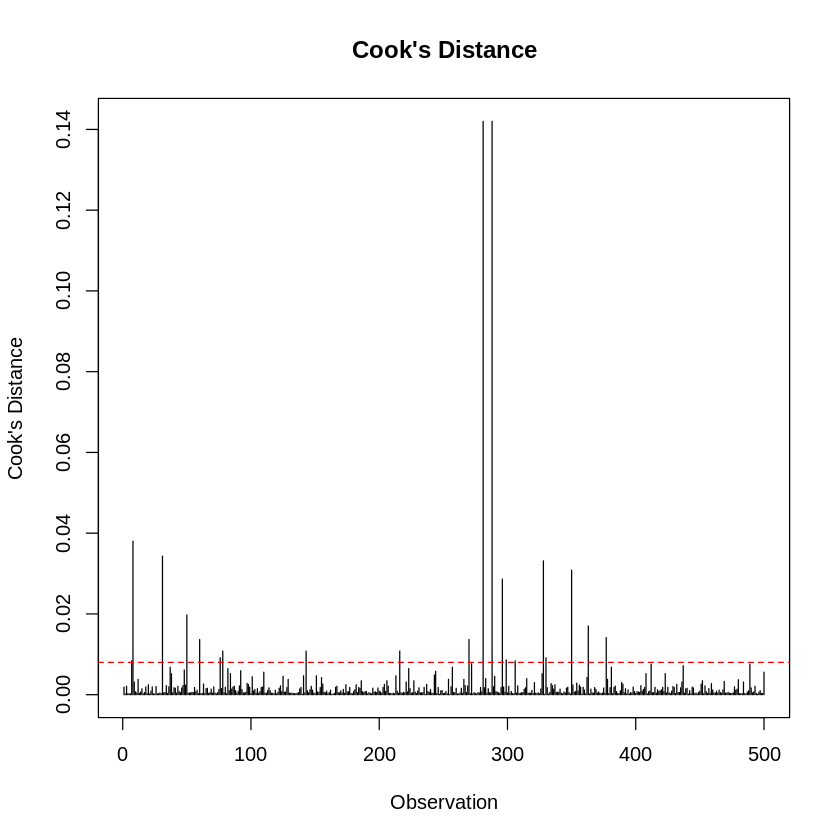

In [16]:
# Calculate Cook's distance
cooks_d <- cooks.distance(model_Glucose)

# Plot it
plot(cooks_d, type = "h",
     main = "Cook's Distance",
     ylab = "Cook's Distance",
     xlab = "Observation")

# Add threshold line
abline(h = 4/nrow(model_data), col = "red", lty = 2)

## Q12: Run Model calibration for your model and data (do not attempt, for next assingment))
1. What does calibration mean in logistic regression?

ANSWER:
1. Calibration in logistic regression means checking whether the model's predicted probabilites really match. The Hosmer-Lemeshow Test is good for this situation becasue the outcome is binary, and it was designed for binary outcomes. It's p-value tells us if the model calibrated well.

In [17]:
install.packages("ResourceSelection")
library(ResourceSelection)

# Hosmer-Lemeshow test
hoslem.test(as.numeric(as.character(model_data$Outcome)), fitted(model_Glucose))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘pbapply’


ResourceSelection 0.3-6 	 2023-06-27




	Hosmer and Lemeshow goodness of fit (GOF) test

data:  as.numeric(as.character(model_data$Outcome)), fitted(model_Glucose)
X-squared = 3.8878, df = 8, p-value = 0.8671


### Q13: Final interpretation
Based on your analysis:
1. Which variable has the highest odds ratio for predicting diabetes?
2. Write down statistical interpretation of this odds ratio.  
Points: 10

ANSWERS:
1. Pregnancies had the highest OR of 1.129.
2. Meaning for every additional pregnancy, the odds of diabetes increases by 1.129, which means each additional pregnancy is associated with about 13% increase in odds of developing diabetes.

## Bonus Question:
Manully code IRLS method to fit your logistic regression and compare the results with results from `glm()` function

Notes: IRLS (Iteratively Reweghted Least Squares) is used by glm() behind the scenes to fit logistic regression. This step is to show step by step instead of R automatically doing it with glm().

In [19]:
#attempting
#set up data
X <- cbind(1, model_data$Glucose)
y <- as.numeric(as.character(model_data$Outcome))

#start with guessing with zero
beta <- c(0, 0)

In [21]:
#calculate predicted probabilities starting from guessing zero
p <- 1 / (1 + exp(-X %*% beta))

#looking at those probabilities
#this is the starting point
head(p)

0.5
0.5
0.5
0.5
0.5
0.5


This tells us we have no inofrmation and that patients have 50/50 chance of having diabetes. With IRLS, we improve these probabilites until they look like realistic patterns in the data.